<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/19B_NeuroFHIR_TRACE_REAL_ADNI_Reliability_Longitudinal_NO_UPLOAD_WIDGET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 19B-REAL
## Real ADNI1 Technical Reliability + Longitudinal Change Analysis

**Purpose:** replace the earlier demo/synthetic reliability analysis with real ADNI1 evidence.

**Inputs**
- `TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv` — real baseline + 12-month ADNI1 cohort.
- `TRACE_ADNI1_repeat_pairs_REAL.csv` — real repeated subject-visit pairs.

**Primary technical arm:** same-day different acquisitions.  
**Secondary technical arm:** same-source repeated-processing records, analyzed separately.

This notebook estimates biomarker-specific repeatability, compares technical disagreement with real 12-month change, and creates aggregate publication-oriented outputs. Participant-level ADNI-derived inputs remain local/private.


In [3]:

import json, hashlib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
SEED=2027
OUTDIR=Path("trace_19b_real_outputs"); OUTDIR.mkdir(exist_ok=True)
print("Output directory:", OUTDIR.resolve())


Output directory: /content/trace_19b_real_outputs


## 1. Load the two real ADNI-derived CSV files

Run the next cell. If the files are not already present, it will prompt **twice**:

1. Upload `TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv` and wait for 100%.
2. Upload `TRACE_ADNI1_repeat_pairs_REAL.csv` and wait for 100%.

Upload **only the file requested at each prompt**. The loader explicitly saves the uploaded bytes and also tolerates browser-renamed copies such as `(1)`.



## File upload method for Colab

**Do not use the browser upload widget inside Python.**

Before running the loader cell:

1. Click the **folder icon** in the left Colab sidebar.
2. Click **Upload**.
3. Upload both:
   - `TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv`
   - `TRACE_ADNI1_repeat_pairs_REAL.csv`
4. Wait until both filenames appear under `/content`.
5. Run the loader cell below.

This avoids the Colab `RangeError: Maximum call stack size exceeded` upload-widget failure.


In [4]:

# ============================================================
# ROBUST FILE LOADER — NO google.colab.files.upload()
# ============================================================
# Why: some Colab sessions throw:
#   MessageError: RangeError: Maximum call stack size exceeded
# from the browser upload widget.
#
# Instead:
# 1) In Colab, click the folder icon on the LEFT.
# 2) Click Upload.
# 3) Upload BOTH CSV files.
# 4) Wait until both are visible under /content.
# 5) Then run this cell.
# ============================================================

from pathlib import Path
import pandas as pd

EXPECTED_LONG = "TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv"
EXPECTED_REP = "TRACE_ADNI1_repeat_pairs_REAL.csv"

SEARCH_DIRS = [
    Path("/content"),
    Path.cwd(),
    Path("/mnt/data"),
]

def find_file(expected_name):
    stem = Path(expected_name).stem
    suffix = Path(expected_name).suffix.lower()

    # Exact filename first
    for d in SEARCH_DIRS:
        p = d / expected_name
        if p.exists():
            return p

    # Browser-renamed copies, e.g. file (1).csv
    candidates = []
    for d in SEARCH_DIRS:
        if not d.exists():
            continue
        for p in d.glob(f"{stem}*{suffix}"):
            if p.is_file():
                candidates.append(p)

    if candidates:
        candidates = sorted(
            candidates,
            key=lambda p: p.stat().st_mtime,
            reverse=True
        )
        return candidates[0]

    return None

LONGITUDINAL_PATH = find_file(EXPECTED_LONG)
REPEAT_PATH = find_file(EXPECTED_REP)

print("Files currently visible to this runtime:")
for d in SEARCH_DIRS:
    if d.exists():
        found = sorted([p.name for p in d.glob("*.csv")])
        if found:
            print(f"  {d}:")
            for name in found:
                print("   -", name)

if LONGITUDINAL_PATH is None or REPEAT_PATH is None:
    missing = []
    if LONGITUDINAL_PATH is None:
        missing.append(EXPECTED_LONG)
    if REPEAT_PATH is None:
        missing.append(EXPECTED_REP)

    raise FileNotFoundError(
        "\nMissing required file(s):\n  - "
        + "\n  - ".join(missing)
        + "\n\nDo NOT use files.upload(). "
          "Use Colab's LEFT Files pane -> Upload, "
          "wait until BOTH files appear under /content, "
          "then rerun this cell."
    )

print("\nUsing longitudinal file:", LONGITUDINAL_PATH)
print("Using repeat-pair file:", REPEAT_PATH)

long_df = pd.read_csv(LONGITUDINAL_PATH)
rep_df = pd.read_csv(REPEAT_PATH)

print("\nSUCCESS")
print("Longitudinal shape:", long_df.shape)
print("Repeat-pair shape:", rep_df.shape)


Files currently visible to this runtime:
  /content:
   - TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv
   - TRACE_ADNI1_repeat_pairs_REAL.csv
  /content:
   - TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv
   - TRACE_ADNI1_repeat_pairs_REAL.csv

Using longitudinal file: /content/TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv
Using repeat-pair file: /content/TRACE_ADNI1_repeat_pairs_REAL.csv

SUCCESS
Longitudinal shape: (258, 51)
Repeat-pair shape: (90, 51)


## 2. Schema and cohort audit

In [5]:

FEATURES=["LHIPPOC","RHIPPOC","LENTORHIN","RENTORHIN","LMIDTEMP","RMIDTEMP","VENTRICLES","ICV"]
required_long=["RID","LABEL","INTERVAL_MONTHS"]+[f"BL_{f}" for f in FEATURES]+[f"M12_{f}" for f in FEATURES]+[f"DELTA_{f}" for f in FEATURES]
required_rep=["RID","VISCODE","REPEAT_TYPE"]+[f"{f}_1" for f in FEATURES]+[f"{f}_2" for f in FEATURES]+[f"PCT_DIFF_{f}" for f in FEATURES]
ml=[x for x in required_long if x not in long_df.columns]; mr=[x for x in required_rep if x not in rep_df.columns]
if ml: raise ValueError(f"Missing longitudinal columns: {ml}")
if mr: raise ValueError(f"Missing repeat columns: {mr}")
print("Longitudinal subjects:", long_df.RID.nunique())
print(long_df.LABEL.value_counts(dropna=False))
print("\nMRI interval months:")
print(long_df.INTERVAL_MONTHS.describe())
print("\nRepeat pairs:", len(rep_df), "subjects:", rep_df.RID.nunique())
print(rep_df.REPEAT_TYPE.value_counts(dropna=False))


Longitudinal subjects: 258
LABEL
pMCI    140
sMCI    118
Name: count, dtype: int64

MRI interval months:
count    258.000000
mean      12.874775
std        0.758789
min       11.466119
25%       12.418891
50%       12.714579
75%       13.232033
max       16.098563
Name: INTERVAL_MONTHS, dtype: float64

Repeat pairs: 90 subjects: 70
REPEAT_TYPE
SAME_DAY_DIFFERENT_ACQUISITION    75
SAME_SOURCE_REPROCESSING          15
Name: count, dtype: int64


## 3. Separate acquisition repeats from repeated-processing records

In [6]:

ACQ_TYPE="SAME_DAY_DIFFERENT_ACQUISITION"; REPROC_TYPE="SAME_SOURCE_REPROCESSING"
acq=rep_df[rep_df.REPEAT_TYPE==ACQ_TYPE].copy(); reproc=rep_df[rep_df.REPEAT_TYPE==REPROC_TYPE].copy()
print("Primary same-day acquisition pairs:", len(acq), "subjects:", acq.RID.nunique())
print("Secondary repeated-processing pairs:", len(reproc), "subjects:", reproc.RID.nunique())


Primary same-day acquisition pairs: 75 subjects: 60
Secondary repeated-processing pairs: 15 subjects: 12


## 4. Reliability functions

In [7]:

def icc_2_1(x,y):
    a=np.column_stack([x,y]).astype(float); a=a[np.isfinite(a).all(axis=1)]
    n,k=a.shape
    if n<3: return np.nan
    g=a.mean(); rm=a.mean(1); cm=a.mean(0)
    ssr=k*np.sum((rm-g)**2); ssc=n*np.sum((cm-g)**2); sst=np.sum((a-g)**2); sse=sst-ssr-ssc
    msr=ssr/(n-1); msc=ssc/(k-1); mse=sse/((n-1)*(k-1))
    den=msr+(k-1)*mse+k*(msc-mse)/n
    return np.nan if den==0 else (msr-mse)/den

def bland_altman(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); m=np.isfinite(x)&np.isfinite(y); d=y[m]-x[m]
    md=d.mean(); sd=d.std(ddof=1)
    return md, md-1.96*sd, md+1.96*sd

def pair_cv(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); mean=(x+y)/2; sd=np.abs(x-y)/np.sqrt(2)
    out=np.full(len(mean),np.nan); ok=np.isfinite(mean)&np.isfinite(sd)&(np.abs(mean)>0); out[ok]=100*sd[ok]/np.abs(mean[ok]); return out

def boot_ci(v, stat=np.median, n_boot=2000, seed=SEED):
    v=np.asarray(v,float); v=v[np.isfinite(v)]
    if len(v)<2: return (np.nan,np.nan)
    r=np.random.default_rng(seed); s=[stat(r.choice(v,len(v),replace=True)) for _ in range(n_boot)]
    return tuple(np.percentile(s,[2.5,97.5]))

def boot_icc(x,y,n_boot=1000,seed=SEED):
    x=np.asarray(x,float); y=np.asarray(y,float); m=np.isfinite(x)&np.isfinite(y); x=x[m]; y=y[m]
    if len(x)<3: return (np.nan,np.nan)
    r=np.random.default_rng(seed); vals=[]
    for _ in range(n_boot):
        idx=r.choice(np.arange(len(x)),len(x),replace=True); vals.append(icc_2_1(x[idx],y[idx]))
    vals=np.asarray(vals,float); vals=vals[np.isfinite(vals)]
    return tuple(np.percentile(vals,[2.5,97.5])) if len(vals) else (np.nan,np.nan)


## 5. Primary same-day acquisition repeatability

In [8]:

rows=[]
for f in FEATURES:
    x=pd.to_numeric(acq[f"{f}_1"],errors="coerce").to_numpy(); y=pd.to_numeric(acq[f"{f}_2"],errors="coerce").to_numpy(); pct=pd.to_numeric(acq[f"PCT_DIFF_{f}"],errors="coerce").to_numpy()
    md,lo,hi=bland_altman(x,y); ici=boot_icc(x,y); pci=boot_ci(pct)
    rows.append(dict(feature=f,n_pairs=int(np.sum(np.isfinite(x)&np.isfinite(y))),icc_2_1=icc_2_1(x,y),icc_ci_low=ici[0],icc_ci_high=ici[1],median_abs_pct_diff=np.nanmedian(pct),median_abs_pct_diff_ci_low=pci[0],median_abs_pct_diff_ci_high=pci[1],p95_abs_pct_diff=np.nanpercentile(pct,95),median_pair_cv_pct=np.nanmedian(pair_cv(x,y)),ba_mean_diff=md,ba_loa_lower=lo,ba_loa_upper=hi))
technical=pd.DataFrame(rows)
display(technical.round(4))


,feature,n_pairs,icc_2_1,icc_ci_low,icc_ci_high,median_abs_pct_diff,median_abs_pct_diff_ci_low,median_abs_pct_diff_ci_high,p95_abs_pct_diff,median_pair_cv_pct,ba_mean_diff,ba_loa_lower,ba_loa_upper
0,LHIPPOC,75,0.9696,0.9406,0.9853,2.8507,2.1092,3.8462,11.3661,2.0157,-14.6133,-330.9784,301.7517
1,RHIPPOC,75,0.9889,0.9835,0.9927,2.1271,1.8507,2.8679,8.7829,1.5041,-9.4133,-217.9560,199.1293
2,LENTORHIN,75,0.8453,0.7727,0.8929,14.5680,10.4502,16.5179,44.7638,10.3011,-5.7600,-555.8440,544.3240
3,RENTORHIN,75,0.7978,0.7075,0.8611,13.7931,8.0925,17.4744,54.0971,9.7532,-8.2267,-631.4159,614.9626
4,LMIDTEMP,75,0.9598,0.9170,0.9824,3.3702,2.4122,4.0802,14.5792,2.3831,-18.2133,-1053.4079,1016.9813
5,RMIDTEMP,75,0.9707,0.9528,0.9818,3.1946,2.3876,4.3861,13.2691,2.2589,-24.4533,-1068.7757,1019.8690
6,VENTRICLES,75,0.9987,0.9954,0.9999,0.5382,0.3838,0.6311,2.2725,0.3806,-77.2133,-2666.6977,2512.2710
7,ICV,75,0.9989,0.9970,0.9997,0.1422,0.1003,0.1703,0.7175,0.1005,219.0667,-13054.4464,13492.5798


## 6. Secondary repeated-processing sensitivity

In [9]:

rows=[]
for f in FEATURES:
    x=pd.to_numeric(reproc[f"{f}_1"],errors="coerce").to_numpy(); y=pd.to_numeric(reproc[f"{f}_2"],errors="coerce").to_numpy(); pct=pd.to_numeric(reproc[f"PCT_DIFF_{f}"],errors="coerce").to_numpy()
    rows.append(dict(feature=f,n_pairs=int(np.sum(np.isfinite(x)&np.isfinite(y))),icc_2_1=icc_2_1(x,y),median_abs_pct_diff=np.nanmedian(pct),p95_abs_pct_diff=np.nanpercentile(pct,95)))
secondary=pd.DataFrame(rows)
display(secondary.round(4))


,feature,n_pairs,icc_2_1,median_abs_pct_diff,p95_abs_pct_diff
0,LHIPPOC,15,0.9893,2.3806,4.5435
1,RHIPPOC,15,0.9966,1.1816,2.9966
2,LENTORHIN,15,0.7551,8.0542,40.5585
3,RENTORHIN,15,0.9197,10.6096,21.9259
4,LMIDTEMP,15,0.9858,1.5954,6.3179
5,RMIDTEMP,15,0.9921,1.7088,6.0432
6,VENTRICLES,15,0.9997,0.5622,1.3961
7,ICV,15,0.9989,0.5805,0.7901


## 7. Real 12-month longitudinal change

In [10]:

long_pct={}; rows=[]
for f in FEATURES:
    bl=pd.to_numeric(long_df[f"BL_{f}"],errors="coerce"); d=pd.to_numeric(long_df[f"DELTA_{f}"],errors="coerce"); pct=(100*np.abs(d)/np.abs(bl)).replace([np.inf,-np.inf],np.nan); long_pct[f]=pct; ci=boot_ci(pct)
    rows.append(dict(feature=f,n_subjects=int(pct.notna().sum()),median_abs_longitudinal_pct_change=float(pct.median()),median_longitudinal_ci_low=ci[0],median_longitudinal_ci_high=ci[1],p25_abs_longitudinal_pct_change=float(pct.quantile(.25)),p75_abs_longitudinal_pct_change=float(pct.quantile(.75)),p95_abs_longitudinal_pct_change=float(pct.quantile(.95)),median_raw_delta=float(d.median())))
longitudinal=pd.DataFrame(rows)
display(longitudinal.round(4))


,feature,n_subjects,median_abs_longitudinal_pct_change,median_longitudinal_ci_low,median_longitudinal_ci_high,p25_abs_longitudinal_pct_change,p75_abs_longitudinal_pct_change,p95_abs_longitudinal_pct_change,median_raw_delta
0,LHIPPOC,258,3.8973,3.3437,4.7375,1.6757,6.8299,12.1989,-105.0
1,RHIPPOC,258,3.9083,3.3609,4.4787,1.7144,6.7229,10.9116,-94.0
2,LENTORHIN,258,13.2603,10.4302,14.6871,5.8919,21.5318,43.0760,-56.0
3,RENTORHIN,258,12.9180,10.8421,14.9488,6.4156,22.8375,42.9464,-63.5
4,LMIDTEMP,258,4.1846,3.6870,5.0686,2.2229,7.5766,12.6034,-266.5
5,RMIDTEMP,258,3.7115,3.2929,4.2161,1.5354,6.0052,12.2476,-275.0
6,VENTRICLES,258,7.0312,6.4649,7.5751,3.9626,10.6702,17.4180,2425.5
7,ICV,258,0.3933,0.3580,0.4692,0.1926,0.8040,1.6517,815.0


## 8. Technical-to-longitudinal change ratio

In [11]:

tech_vs_long=technical.merge(longitudinal,on="feature")
tech_vs_long["technical_to_longitudinal_ratio"]=tech_vs_long.median_abs_pct_diff/tech_vs_long.median_abs_longitudinal_pct_change
tech_vs_long["longitudinal_to_technical_ratio"]=tech_vs_long.median_abs_longitudinal_pct_change/tech_vs_long.median_abs_pct_diff
display(tech_vs_long[["feature","median_abs_pct_diff","median_abs_longitudinal_pct_change","technical_to_longitudinal_ratio","icc_2_1","p95_abs_pct_diff"]].sort_values("technical_to_longitudinal_ratio",ascending=False).round(4))


,feature,median_abs_pct_diff,median_abs_longitudinal_pct_change,technical_to_longitudinal_ratio,icc_2_1,p95_abs_pct_diff
2,LENTORHIN,14.5680,13.2603,1.0986,0.8453,44.7638
3,RENTORHIN,13.7931,12.9180,1.0677,0.7978,54.0971
5,RMIDTEMP,3.1946,3.7115,0.8607,0.9707,13.2691
4,LMIDTEMP,3.3702,4.1846,0.8054,0.9598,14.5792
0,LHIPPOC,2.8507,3.8973,0.7314,0.9696,11.3661
1,RHIPPOC,2.1271,3.9083,0.5442,0.9889,8.7829
7,ICV,0.1422,0.3933,0.3616,0.9989,0.7175
6,VENTRICLES,0.5382,7.0312,0.0766,0.9987,2.2725


## 9. Empirical technical ambiguity

In [12]:

threshold_map=dict(zip(technical.feature,technical.p95_abs_pct_diff))
amb=pd.DataFrame({"RID":long_df.RID,"LABEL":long_df.LABEL})
for f in FEATURES:
    amb[f"{f}_ABS_LONG_PCT"]=long_pct[f]; amb[f"{f}_TECH_P95"]=threshold_map[f]; amb[f"{f}_AMBIGUOUS"]=long_pct[f] <= threshold_map[f]
BIO_FEATURES=[f for f in FEATURES if f!="ICV"]
amb["N_AMBIGUOUS_BIO_FEATURES"]=amb[[f"{f}_AMBIGUOUS" for f in BIO_FEATURES]].sum(axis=1)
feature_ambiguity=pd.DataFrame([{"feature":f,"technical_p95_pct_threshold":threshold_map[f],"n_ambiguous":int(amb[f"{f}_AMBIGUOUS"].sum()),"pct_ambiguous":100*float(amb[f"{f}_AMBIGUOUS"].mean())} for f in BIO_FEATURES])
display(feature_ambiguity.sort_values("pct_ambiguous",ascending=False).round(3))
print("Subjects with >=1 ambiguous biological feature:", int((amb.N_AMBIGUOUS_BIO_FEATURES>=1).sum()))
print("Subjects with >=2 ambiguous biological features:", int((amb.N_AMBIGUOUS_BIO_FEATURES>=2).sum()))
print("Subjects with >=3 ambiguous biological features:", int((amb.N_AMBIGUOUS_BIO_FEATURES>=3).sum()))


,feature,technical_p95_pct_threshold,n_ambiguous,pct_ambiguous
3,RENTORHIN,54.097,253,98.062
4,LMIDTEMP,14.579,251,97.287
5,RMIDTEMP,13.269,248,96.124
2,LENTORHIN,44.764,247,95.736
0,LHIPPOC,11.366,241,93.411
1,RHIPPOC,8.783,226,87.597
6,VENTRICLES,2.273,30,11.628


Subjects with >=1 ambiguous biological feature: 258
Subjects with >=2 ambiguous biological features: 258
Subjects with >=3 ambiguous biological features: 257


## 10. QC disagreement versus technical error

In [13]:

pct_cols=[f"PCT_DIFF_{f}" for f in FEATURES]
for col in pct_cols: rep_df[col]=pd.to_numeric(rep_df[col],errors="coerce")
rep_df["MEDIAN_BIOMARKER_ERROR_PCT"]=rep_df[pct_cols].median(axis=1)
for a,b,out in [("QC_1","QC_2","QC_DISAGREEMENT"),("TEMPQC_1","TEMPQC_2","TEMPQC_DISAGREEMENT"),("VENTQC_1","VENTQC_2","VENTQC_DISAGREEMENT")]:
    if a in rep_df and b in rep_df: rep_df[out]=rep_df[a].astype(str)!=rep_df[b].astype(str)
qcrows=[]
for name,col in [("overall_qc","QC_DISAGREEMENT"),("temporal_qc","TEMPQC_DISAGREEMENT"),("ventricle_qc","VENTQC_DISAGREEMENT")]:
    if col in rep_df:
        for flag in [False,True]:
            v=rep_df.loc[rep_df[col]==flag,"MEDIAN_BIOMARKER_ERROR_PCT"]
            qcrows.append(dict(qc_type=name,disagreement=flag,n_pairs=len(v),median_overall_technical_error_pct=float(v.median()) if len(v) else np.nan))
qc_error_summary=pd.DataFrame(qcrows)
display(qc_error_summary.round(4))


,qc_type,disagreement,n_pairs,median_overall_technical_error_pct
0,overall_qc,False,57,2.1756
1,overall_qc,True,33,2.4192
2,temporal_qc,False,69,2.2164
3,temporal_qc,True,21,2.3844
4,ventricle_qc,False,75,2.1234
5,ventricle_qc,True,15,4.3830


## 11. Publication-oriented figures

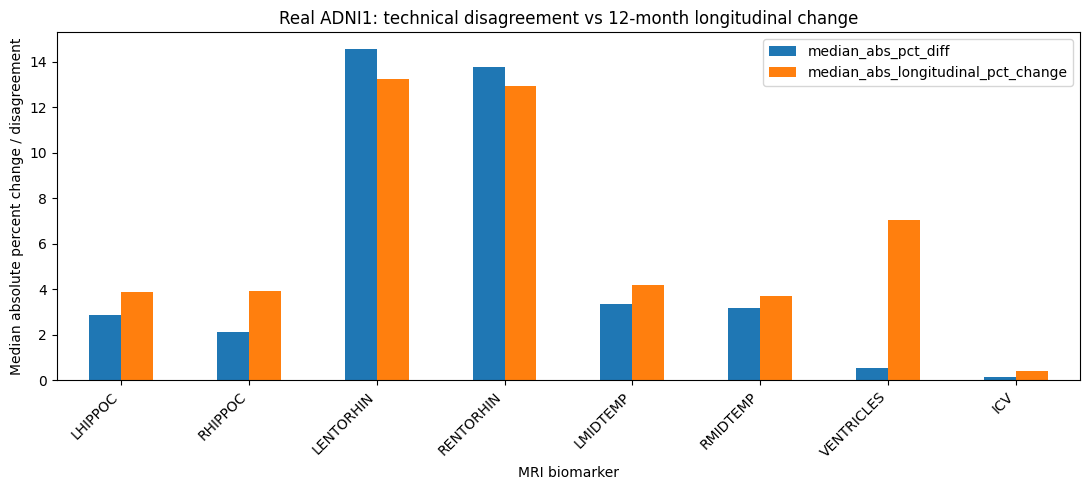

In [14]:

plot_df=tech_vs_long.set_index("feature")[["median_abs_pct_diff","median_abs_longitudinal_pct_change"]]
ax=plot_df.plot(kind="bar",figsize=(11,5)); ax.set_ylabel("Median absolute percent change / disagreement"); ax.set_xlabel("MRI biomarker"); ax.set_title("Real ADNI1: technical disagreement vs 12-month longitudinal change"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.savefig(OUTDIR/"figure_technical_vs_longitudinal.png",dpi=300,bbox_inches="tight"); plt.show()


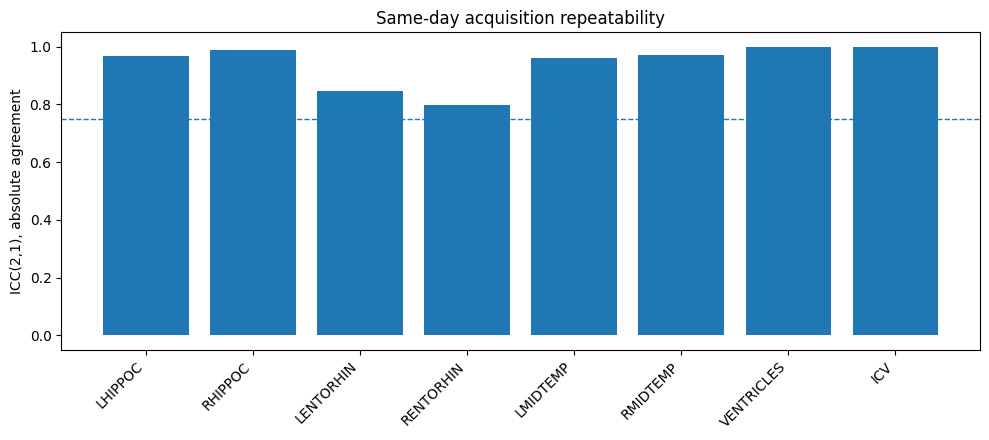

In [15]:

fig,ax=plt.subplots(figsize=(10,4.5)); ax.bar(technical.feature,technical.icc_2_1); ax.axhline(.75,linestyle="--",linewidth=1); ax.set_ylim(min(-.05,float(np.nanmin(technical.icc_2_1))-.05),1.05); ax.set_ylabel("ICC(2,1), absolute agreement"); ax.set_title("Same-day acquisition repeatability"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.savefig(OUTDIR/"figure_same_day_icc.png",dpi=300,bbox_inches="tight"); plt.show()


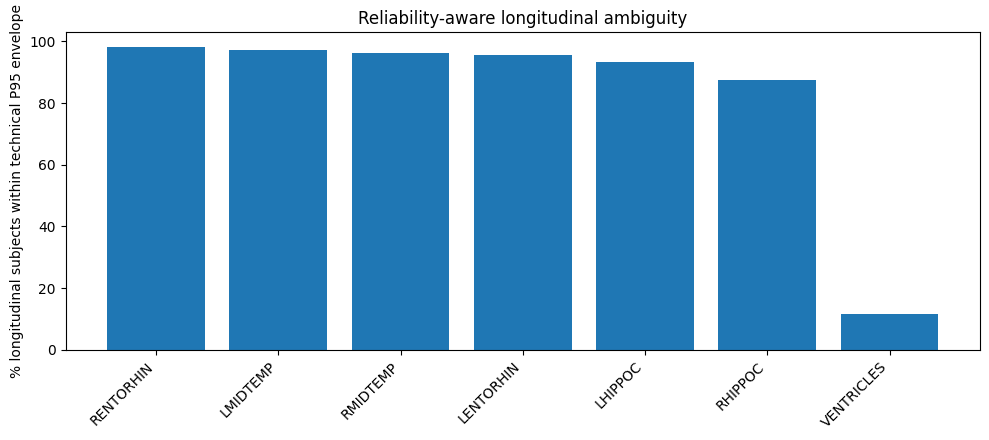

In [16]:

fd=feature_ambiguity.sort_values("pct_ambiguous",ascending=False); fig,ax=plt.subplots(figsize=(10,4.5)); ax.bar(fd.feature,fd.pct_ambiguous); ax.set_ylabel("% longitudinal subjects within technical P95 envelope"); ax.set_title("Reliability-aware longitudinal ambiguity"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.savefig(OUTDIR/"figure_longitudinal_ambiguity.png",dpi=300,bbox_inches="tight"); plt.show()


## 12. Aggregate exports only

In [17]:

technical.to_csv(OUTDIR/"table_same_day_reliability.csv",index=False)
secondary.to_csv(OUTDIR/"table_reprocessing_sensitivity.csv",index=False)
longitudinal.to_csv(OUTDIR/"table_longitudinal_change.csv",index=False)
tech_vs_long.to_csv(OUTDIR/"table_technical_vs_longitudinal.csv",index=False)
feature_ambiguity.to_csv(OUTDIR/"table_feature_ambiguity.csv",index=False)
qc_error_summary.to_csv(OUTDIR/"table_qc_error_summary.csv",index=False)
print("Aggregate outputs:")
for p in sorted(OUTDIR.iterdir()): print(" -",p.name)


Aggregate outputs:
 - figure_longitudinal_ambiguity.png
 - figure_same_day_icc.png
 - figure_technical_vs_longitudinal.png
 - table_feature_ambiguity.csv
 - table_longitudinal_change.csv
 - table_qc_error_summary.csv
 - table_reprocessing_sensitivity.csv
 - table_same_day_reliability.csv
 - table_technical_vs_longitudinal.csv


## 13. Reproducibility manifest

In [19]:
import hashlib
import json

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    "notebook": "19B-REAL",
    "seed": SEED,
    "input_files": {
        LONGITUDINAL_PATH.name: sha256_file(LONGITUDINAL_PATH),
        REPEAT_PATH.name: sha256_file(REPEAT_PATH),
    },
    "cohort": {
        "longitudinal_subjects": int(long_df["RID"].nunique()),
        "same_day_acquisition_pairs": int(len(acq)),
        "same_day_acquisition_subjects": int(acq["RID"].nunique()),
        "reprocessing_pairs": int(len(reproc)),
        "reprocessing_subjects": int(reproc["RID"].nunique()),
    }
}

with open(OUTDIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

manifest

{'notebook': '19B-REAL',
 'seed': 2027,
 'input_files': {'TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv': 'f627bd017e3287b2bad7b6894372e7c5c78bffa2e73f1c92f9d89d6274d03dea',
  'TRACE_ADNI1_repeat_pairs_REAL.csv': '3a600b5cf11df11d2511e51ebbc933eed8be3d04305b7b281271d058c37ab926'},
 'cohort': {'longitudinal_subjects': 258,
  'same_day_acquisition_pairs': 75,
  'same_day_acquisition_subjects': 60,
  'reprocessing_pairs': 15,
  'reprocessing_subjects': 12}}

## 14. Automated readiness summary

In [20]:

print("="*60); print("19B-REAL READINESS SUMMARY"); print("="*60)
print("Longitudinal subjects:", long_df.RID.nunique())
print("Same-day different-acquisition pairs:", len(acq))
print("Same-day acquisition subjects:", acq.RID.nunique())
print("Repeated-processing pairs:", len(reproc))
print("\nCore biomarker reliability table:")
display(tech_vs_long[["feature","n_pairs","icc_2_1","median_abs_pct_diff","p95_abs_pct_diff","median_abs_longitudinal_pct_change","technical_to_longitudinal_ratio"]].sort_values("technical_to_longitudinal_ratio",ascending=False).round(4))
print("\nGuardrails:")
print("- Same-day repeats are described as same-day different acquisitions, not automatically formal test-retest scans.")
print("- Reprocessing records remain separate secondary evidence.")
print("- Technical ambiguity is an engineering reliability construct, not clinical ground truth.")
print("- Participant-level ADNI-derived inputs remain private/local and are not exported by this notebook.")


19B-REAL READINESS SUMMARY
Longitudinal subjects: 258
Same-day different-acquisition pairs: 75
Same-day acquisition subjects: 60
Repeated-processing pairs: 15

Core biomarker reliability table:


,feature,n_pairs,icc_2_1,median_abs_pct_diff,p95_abs_pct_diff,median_abs_longitudinal_pct_change,technical_to_longitudinal_ratio
2,LENTORHIN,75,0.8453,14.5680,44.7638,13.2603,1.0986
3,RENTORHIN,75,0.7978,13.7931,54.0971,12.9180,1.0677
5,RMIDTEMP,75,0.9707,3.1946,13.2691,3.7115,0.8607
4,LMIDTEMP,75,0.9598,3.3702,14.5792,4.1846,0.8054
0,LHIPPOC,75,0.9696,2.8507,11.3661,3.8973,0.7314
1,RHIPPOC,75,0.9889,2.1271,8.7829,3.9083,0.5442
7,ICV,75,0.9989,0.1422,0.7175,0.3933,0.3616
6,VENTRICLES,75,0.9987,0.5382,2.2725,7.0312,0.0766



Guardrails:
- Same-day repeats are described as same-day different acquisitions, not automatically formal test-retest scans.
- Reprocessing records remain separate secondary evidence.
- Technical ambiguity is an engineering reliability construct, not clinical ground truth.
- Participant-level ADNI-derived inputs remain private/local and are not exported by this notebook.
